# Notebook 05: Exploratory Data Analysis & Lag Estimation
This notebook estimates the empirical feedback lag ($\tau$) using Spearman cross-correlations, runs the pre-registered event-study parallel trends check, and performs exploratory spectral analysis.

### Important Project Safety Notice

Before executing or citing the findings in this notebook, please read the public guidance on what this project is and is not claiming:  

[docs/not_saying.md](../docs/not_saying.md) - *What This Theory Is NOT Claiming*

## 1. Library Imports & Data Loading
Load the state-year panel dataset and check its contents.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import spearmanr

df = pd.read_csv('../data/processed/state_year_panel.csv')
print(f'Data loaded successfully. Panel size: {df.shape}')
print('Columns in dataset:', list(df.columns))

Data loaded successfully. Panel size: (765, 38)
Columns in dataset: ['state', 'year', 'covid_era', 'primary_analysis_window', 'raw_intensity', 'policy_intensity', 'norm', 'svi_common_core', 'svi_highway', 'svi_opt_out', 'svi_testing', 'total_events', 'edu_events', 'highway_events', 'gdelt_edu_salience', 'gdelt_highway_salience', 'gdelt_edu_salience_std', 'svi_common_core_std', 'svi_testing_std', 'svi_opt_out_std', 'backlash_media', 'backlash_media_winsorized', 'gdelt_edu_salience_logged', 'backlash_mass', 'gov_party_rep', 'gov_party_change', 'election_year', 'trifecta', 'within_party_stability', 'raw_highway_intensity', 'highway_policy_intensity', 'highway_norm', 'gdelt_highway_salience_std', 'svi_highway_std', 'highway_backlash_media', 'highway_backlash_media_winsorized', 'gdelt_highway_salience_logged', 'highway_backlash_mass']


## 2. Spearman Rank Cross-Correlations on First-Differences (Lag Estimation)
We estimate the state-specific feedback delay lag ($\tau_s$) by finding the temporal shift that maximizes the correlation between first-differenced policy intensity and backlash outcomes.

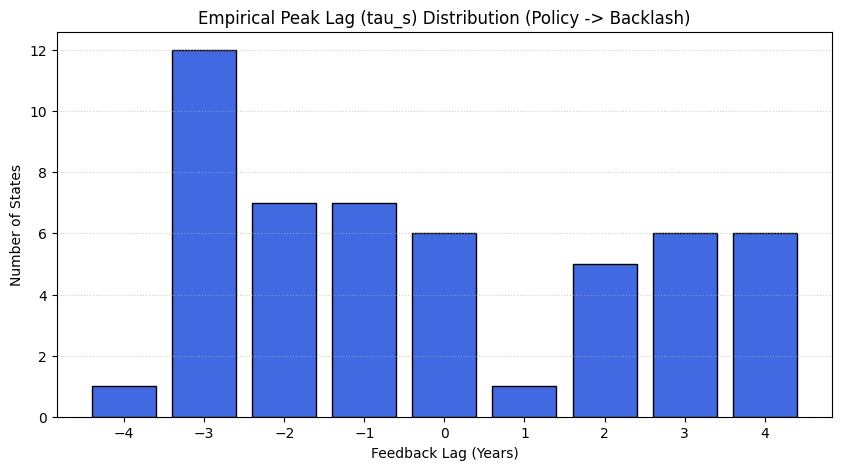

Mean peak lag: -0.1568627450980392
Median peak lag: -1.0


In [2]:
def estimate_state_lag(df, state_code, backlash_col='backlash_media'):
    state_df = df[df['state'] == state_code].sort_values('year')
    diff_p = state_df['policy_intensity'].diff().values[1:]
    diff_b = state_df[backlash_col].diff().values[1:]
    
    lags = range(-4, 5)  # -4 to +4
    corrs = []
    for lag in lags:
        if lag > 0:
            p_part = diff_p[:-lag]
            b_part = diff_b[lag:]
        elif lag < 0:
            p_part = diff_p[-lag:]
            b_part = diff_b[:lag]
        else:
            p_part = diff_p
            b_part = diff_b
            
        if len(p_part) >= 5:
            corr, _ = spearmanr(p_part, b_part)
            corrs.append(corr)
        else:
            corrs.append(np.nan)
    return list(lags), corrs

# Compute peak lags across all states
peak_lags = {}
states = df['state'].unique()
for s in states:
    lags, corrs = estimate_state_lag(df, s, 'backlash_media')
    valid_corrs = [c for c in corrs if not np.isnan(c)]
    if valid_corrs:
        max_idx = np.nanargmax(corrs)
        peak_lags[s] = lags[max_idx]

# Plot the histogram of peak lags
plt.figure(figsize=(10, 5))
plt.hist(peak_lags.values(), bins=np.arange(-4.5, 5.5, 1), rwidth=0.8, color='royalblue', edgecolor='black')
plt.xlabel('Feedback Lag (Years)')
plt.ylabel('Number of States')
plt.title('Empirical Peak Lag (tau_s) Distribution (Policy -> Backlash)')
plt.xticks(range(-4, 5))
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()

print('Mean peak lag:', np.mean(list(peak_lags.values())))
print('Median peak lag:', np.median(list(peak_lags.values())))

## 3. Formal Event-Study Pre-Trend Regression
We regress backlash indicators on interactions between pre-treatment continuous dosage (pre-ESSA policy intensity average) and year dummies, with state and year fixed effects. This formally tests the parallel pre-trends assumption.

In [3]:
# 1. Calculate continuous dosage (average pre-ESSA policy intensity 2010-2014)
pre_essa_mean = df[df['year'] <= 2014].groupby('state')['policy_intensity'].mean().reset_index()
pre_essa_mean.rename(columns={'policy_intensity': 'pre_essa_dosage'}, inplace=True)
df_event = df.merge(pre_essa_mean, on='state')

# 2. Prepare event-study interactions, leaving 2014 as the reference year
event_years = [y for y in range(2010, 2025) if y != 2014]
for y in event_years:
    df_event[f'dosage_x_{y}'] = df_event['pre_essa_dosage'] * (df_event['year'] == y).astype(int)

# 3. Run Event Study on Media Backlash
interaction_terms = ' + '.join([f'dosage_x_{y}' for y in event_years])
formula = f'backlash_media ~ {interaction_terms} + gov_party_rep + trifecta + election_year + C(state) + C(year)'
model_media = smf.ols(formula, data=df_event).fit()

print('=== Event Study on Media Backlash ===')
print(model_media.summary().tables[1])

# Joint F-test on pre-treatment coefficients to verify parallel pre-trends
pre_vars = [f'dosage_x_{y}' for y in range(2010, 2014)]
hypotheses = ', '.join([f'{v} = 0' for v in pre_vars])
f_test_media = model_media.f_test(hypotheses)
print('\n=== Joint F-test for Pre-Trends (2010-2013) ===')
print(f'F-statistic: {float(f_test_media.fvalue):.4f}')
print(f'p-value: {float(f_test_media.pvalue):.4f}')

=== Event Study on Media Backlash ===


                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -1.1628      0.305     -3.813      0.000      -1.761      -0.564
C(state)[T.AL]      0.4664      0.324      1.441      0.150      -0.169       1.102
C(state)[T.AR]      1.1696      0.270      4.338      0.000       0.640       1.699
C(state)[T.AZ]      0.3919      0.412      0.952      0.341      -0.416       1.200
C(state)[T.CA]      0.2299      0.331      0.694      0.488      -0.421       0.880
C(state)[T.CO]      0.2584      0.315      0.819      0.413      -0.361       0.878
C(state)[T.CT]      1.4584      0.284      5.138      0.000       0.901       2.016
C(state)[T.DC]      1.5742      0.381      4.131      0.000       0.826       2.322
C(state)[T.DE]      1.2117      0.381      3.180      0.002       0.464       1.960
C(state)[T.FL]      0.4224      0.284      1.488      0.137      -0.135     

We repeat the event-study parallel trends check on **Mass Backlash** (search volume index).

In [4]:
formula_mass = f'backlash_mass ~ {interaction_terms} + gov_party_rep + trifecta + election_year + C(state) + C(year)'
model_mass = smf.ols(formula_mass, data=df_event).fit()

print('=== Event Study on Mass Backlash ===')
print(model_mass.summary().tables[1])

f_test_mass = model_mass.f_test(hypotheses)
print('\n=== Joint F-test for Pre-Trends (2010-2013) ===')
print(f'F-statistic: {float(f_test_mass.fvalue):.4f}')
print(f'p-value: {float(f_test_mass.pvalue):.4f}')

=== Event Study on Mass Backlash ===
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -1.0152      0.147     -6.927      0.000      -1.303      -0.727
C(state)[T.AL]      0.3262      0.156      2.096      0.036       0.021       0.632
C(state)[T.AR]      0.4739      0.130      3.657      0.000       0.219       0.728
C(state)[T.AZ]      0.3764      0.198      1.903      0.057      -0.012       0.765
C(state)[T.CA]      0.9108      0.159      5.719      0.000       0.598       1.223
C(state)[T.CO]      0.8974      0.152      5.919      0.000       0.600       1.195
C(state)[T.CT]      0.7462      0.136      5.470      0.000       0.478       1.014
C(state)[T.DC]     -0.2535      0.183     -1.384      0.167      -0.613       0.106
C(state)[T.DE]      0.1799      0.183      0.982      0.326      -0.180       0.539
C(state)[T.FL]      0.7903      0.136  

## 4. FFT Spectral Analysis (Descriptive Check)
We run a descriptive Fast Fourier Transform (FFT) analysis on the national aggregate time-series of backlash and attention indicators to examine dominant frequencies over time.

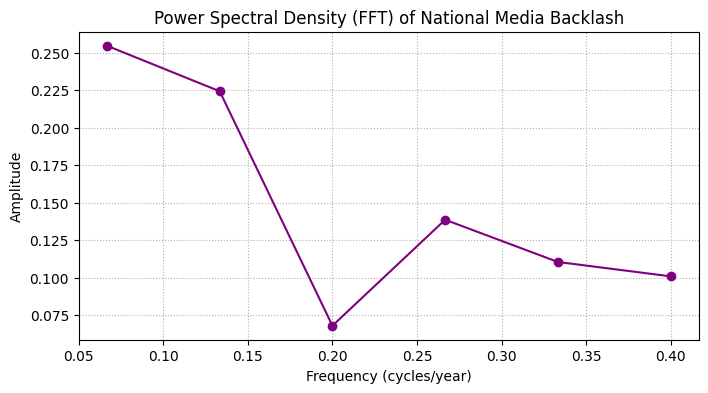

=== FFT Dominant Frequencies ===
Freq: 0.0667 cycles/year -> Period: 15.00 years (Power: 0.2545)
Freq: 0.1333 cycles/year -> Period: 7.50 years (Power: 0.2242)
Freq: 0.2000 cycles/year -> Period: 5.00 years (Power: 0.0681)
Freq: 0.2667 cycles/year -> Period: 3.75 years (Power: 0.1387)
Freq: 0.3333 cycles/year -> Period: 3.00 years (Power: 0.1106)
Freq: 0.4000 cycles/year -> Period: 2.50 years (Power: 0.1010)


In [5]:
# National aggregate time-series
national_b = df.groupby('year')['backlash_media'].mean().values
N_fft = len(national_b)
yf = fft.fft(national_b - np.mean(national_b))
xf = fft.fftfreq(N_fft, 1.0)[:N_fft//2]
power = 2.0/N_fft * np.abs(yf[:N_fft//2])

plt.figure(figsize=(8, 4))
plt.plot(xf[1:], power[1:], color='purple', marker='o')
plt.xlabel('Frequency (cycles/year)')
plt.ylabel('Amplitude')
plt.title('Power Spectral Density (FFT) of National Media Backlash')
plt.grid(True, linestyle=':')
plt.show()

print('=== FFT Dominant Frequencies ===')
for freq, p in zip(xf[1:], power[1:]):
    period = 1.0 / freq if freq > 0 else float('inf')
    print(f'Freq: {freq:.4f} cycles/year -> Period: {period:.2f} years (Power: {p:.4f})')